# 3D Grad-CAM Generation and Lesion-Localization Evaluation — Run 2

## Objective

This notebook evaluates whether discriminative regions identified by the Run 2 3D ResNet-18 PDAC classifier spatially correspond to the annotated PDAC lesion in the processed PANORAMA dataset.

Grad-CAM is generated from the final residual feature stage (`model.layer4`) using the raw classification logit as the backpropagation target. Localization is quantified using Dice and IoU after thresholding the normalized Grad-CAM at multiple predefined thresholds. Pointing Game accuracy provides a threshold-independent complementary measure.

This evaluation is part of the thesis trustworthiness analysis, alongside the separate calibration analysis notebook.

## What this evaluation does and does not establish

Grad-CAM provides a **coarse** spatial explanation of the model's discriminative activity. Its native feature-map resolution is substantially lower than the input volume, and the trilinear interpolation used to restore the CAM to input dimensions does not create true voxel-level localization precision.

Dice and IoU require binarizing the continuous CAM and therefore depend on the selected threshold. To reduce dependence on any single threshold, this notebook reports results across a predefined threshold sweep: `T = {0.3, 0.4, 0.5, 0.6, 0.7}`. `T = 0.5` is retained as a predefined reference threshold, not as a threshold optimized on the test set.

A high localization score is interpreted as being **consistent with lesion-focused discriminative attention**. It is not treated as proof that the model is causally reasoning about the tumor. Grad-CAM is an explanatory localization technique, not a definitive causal faithfulness test -- establishing genuine causal faithfulness would require perturbation-based methods (e.g. deletion/insertion tests: measuring how much the predicted probability drops when high-CAM voxels are masked out), which are out of scope for this notebook and are noted as a possible follow-up experiment, not attempted here.

## The PDAC lesion label

The processed PANORAMA segmentation masks use the documented label map: `0=background, 1=PDAC lesion, 2=veins, 3=arteries, 4=pancreas parenchyma, 5=pancreatic duct, 6=common bile duct`. Thus **PDAC lesion label = 1** and **pancreas label = 4** -- these are separate structures with separate labels and must never be conflated. This was independently verified during dataset auditing (label 1 present in 676/676 PDAC cases and 0/1562 non-PDAC cases -- a perfect correspondence). The tumor label is defined once as a named constant (`PDAC_TUMOR_LABEL`), and Cell 3 re-confirms this empirically against the actual processed test-set files before any GPU-consuming Grad-CAM generation begins.

## Two evaluation questions

- **Analysis A -- all PDAC-positive test cases.** *"When the model is presented with a known PDAC case, where is its discriminative attention located?"* Includes every PDAC-positive test case with a valid lesion annotation, regardless of whether the classifier itself predicts PDAC correctly.
- **Analysis B -- correctly predicted PDAC cases.** *"When the classifier correctly identifies a PDAC case, does its discriminative attention spatially correspond to the annotated lesion?"* Obtained by filtering the already-computed Analysis A per-case results using the predefined classification threshold -- no second Grad-CAM generation pass is required.

Both are reported; neither replaces the other.

## Scope and interpretation

This notebook evaluates **lesion localization**, not complete causal explanation faithfulness. Results should be read together with the classifier's classification performance, the separate calibration results, the qualitative examples, and the objectively identified failure cases below -- not as a single isolated number. Conclusions use language such as *"consistent with lesion-focused discriminative attention"* rather than claiming the model has been proven to *"reason about"* the tumor.


## Cell 1 — Configuration

In [1]:
# ============================================================
# CELL 1 — CONFIGURATION
# ============================================================

import json as json_module
import random
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models.video import r3d_18

# ------------------------------------------------------------
# Kaggle paths — UPDATE THESE for your session.
# ------------------------------------------------------------

PROCESSED_DIR = Path(
    "/kaggle/input/datasets/shahriarahmed66/panorama-processed-dataset"
)
CHECKPOINT_DIR = Path(
    "/kaggle/input/datasets/shahriarahmed66/panorama-run2-best-checkpoint"  # <-- adjust to your attached dataset slug
)
CHECKPOINT_PATH = CHECKPOINT_DIR / "best_model.pt"
SPLIT_PATH = PROCESSED_DIR / "split_assignment.csv"

OUTPUT_DIR = Path("/kaggle/working/gradcam_results")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CAM_VOLUME_DIR = OUTPUT_DIR / "cam_volumes"

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------
# This makes the experiment reproducible (same seed -> same bootstrap
# resamples, same weighted sampling if any). It does NOT claim full
# bitwise GPU determinism -- cudnn.deterministic is deliberately not
# enabled here (as in the training notebook), since not all cuDNN
# algorithms have deterministic implementations for Conv3d and forcing
# it risks a runtime error mid-run for no benefit to this evaluation.

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ------------------------------------------------------------
# PDAC lesion label — documented, previously verified (see markdown
# above), and re-confirmed empirically in Cell 3 before any GPU work.
# ------------------------------------------------------------

PDAC_TUMOR_LABEL = 1     # official PANORAMA label map: 1 = PDAC lesion
PANCREAS_LABEL = 4       # official PANORAMA label map: 4 = pancreas parenchyma (NOT the tumor)

# ------------------------------------------------------------
# Evaluation configuration
# ------------------------------------------------------------

IOU_DICE_THRESHOLDS = [0.3, 0.4, 0.5, 0.6, 0.7]
HEADLINE_THRESHOLD = 0.5     # predefined reference threshold, reported alongside the full sweep

# Same classification threshold used throughout the classifier's own
# training/evaluation notebooks -- not chosen retrospectively here.
PREDICTION_THRESHOLD = 0.5

# Predefined (not tuned on results) criteria for the objective
# failure-case search in Part 20 below.
HIGH_CONFIDENCE_THRESHOLD = 0.8
LOW_DICE_FAILURE_THRESHOLD = 0.1

N_BOOTSTRAP = 2000

# Save full normalized CAM volumes only for selected exemplar cases by
# default, to keep output size manageable.
SAVE_ALL_CAM_VOLUMES = False

# Known from Notebook 18's ROI crop investigation: these two PDAC cases
# had a lesion extending beyond the lateral ROI boundary (92.9%-94.2%
# tumor voxel retention after cropping). Their processed masks are still
# the CORRECT masks for evaluating this classifier (they match the
# processed input grid the model actually saw) -- flagged here for
# transparency, not corrected or reconstructed.
ROI_BOUNDARY_CASE_IDS = ["100936_00001", "101900_00001"]

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ------------------------------------------------------------
# Configuration summary
# ------------------------------------------------------------

print("=" * 70)
print("GRAD-CAM EVALUATION — CONFIGURATION")
print("=" * 70)
print(f"PyTorch version         : {torch.__version__}")
print(f"CUDA available          : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device             : {torch.cuda.get_device_name(0)}")
    print(f"GPU memory              : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"Device                  : {DEVICE}")
print()
print(f"Processed dataset exists: {PROCESSED_DIR.exists()}  ({PROCESSED_DIR})")
print(f"Split file exists       : {SPLIT_PATH.exists()}  ({SPLIT_PATH})")
print(f"Checkpoint exists       : {CHECKPOINT_PATH.exists()}  ({CHECKPOINT_PATH})")
print()
print(f"Seed                    : {SEED}")
print(f"PDAC_TUMOR_LABEL        : {PDAC_TUMOR_LABEL}  (pancreas is separately PANCREAS_LABEL={PANCREAS_LABEL})")
print(f"IoU/Dice thresholds     : {IOU_DICE_THRESHOLDS}")
print(f"Headline threshold      : {HEADLINE_THRESHOLD}")
print(f"Prediction threshold    : {PREDICTION_THRESHOLD}")
print(f"High-confidence threshold (failure search): {HIGH_CONFIDENCE_THRESHOLD}")
print(f"Low-Dice failure threshold                : {LOW_DICE_FAILURE_THRESHOLD}")
print(f"Bootstrap resamples     : {N_BOOTSTRAP}")
print(f"Save all CAM volumes    : {SAVE_ALL_CAM_VOLUMES}")
print(f"Known ROI-boundary cases: {ROI_BOUNDARY_CASE_IDS}")

if DEVICE.type != "cuda":
    print(
        "\nWARNING: no GPU detected. Grad-CAM generation for ~100 cases will "
        "be slow on CPU. Enable a GPU accelerator before running the main loop."
    )


GRAD-CAM EVALUATION — CONFIGURATION
PyTorch version         : 2.10.0+cu128
CUDA available          : True
CUDA device             : Tesla T4
GPU memory              : 15.6 GB
Device                  : cuda

Processed dataset exists: True  (/kaggle/input/datasets/shahriarahmed66/panorama-processed-dataset)
Split file exists       : True  (/kaggle/input/datasets/shahriarahmed66/panorama-processed-dataset/split_assignment.csv)
Checkpoint exists       : True  (/kaggle/input/datasets/shahriarahmed66/panorama-run2-best-checkpoint/best_model.pt)

Seed                    : 42
PDAC_TUMOR_LABEL        : 1  (pancreas is separately PANCREAS_LABEL=4)
IoU/Dice thresholds     : [0.3, 0.4, 0.5, 0.6, 0.7]
Headline threshold      : 0.5
Prediction threshold    : 0.5
High-confidence threshold (failure search): 0.8
Low-Dice failure threshold                : 0.1
Bootstrap resamples     : 2000
Save all CAM volumes    : False
Known ROI-boundary cases: ['100936_00001', '101900_00001']


## Cell 2 — Path handling and centralized data-loading function

The path corrections verified against this exact Kaggle dataset (backslash -> forward slash, and the extra nested `images/images/` / `masks/masks/` level from how the dataset zip was built) are applied through a single idempotent helper. It is safe to re-run this cell any number of times without progressively creating `images/images/images/...` — the helper strips any existing prefix before rebuilding the correct path, and the original `split_df` columns are never mutated in place.

In [2]:
# ============================================================
# CELL 2 — PATH HANDLING AND CENTRALIZED DATA LOADING
# ============================================================

def resolve_processed_path(raw_path, subfolder_name, processed_dir):
    """
    Idempotent path resolver. Strips backslashes and any existing
    "<subfolder_name>/" prefix(es) from raw_path (however many may already
    be present, e.g. if this function was applied more than once to the
    same string), then rebuilds the single verified nested structure:
    <processed_dir>/<subfolder_name>/<subfolder_name>/<filename>.npy

    Safe to call repeatedly on the same or already-resolved input without
    accumulating extra prefixes.
    """
    normalized = str(raw_path).replace("\\", "/")
    prefix = f"{subfolder_name}/"
    while normalized.startswith(prefix):
        normalized = normalized[len(prefix):]
    resolved_relative = f"{subfolder_name}/{subfolder_name}/{normalized}"
    return processed_dir / resolved_relative


def load_volume_and_mask(row, processed_dir, return_raw_mask=False):
    """
    Single centralized function for loading a processed CT volume and its
    binary PDAC lesion mask. This is the ONLY place PDAC_TUMOR_LABEL is
    applied -- no other cell should duplicate this logic.
    """
    image_path = resolve_processed_path(row["image_path"], "images", processed_dir)
    mask_path = resolve_processed_path(row["mask_path"], "masks", processed_dir)

    if not image_path.exists():
        raise FileNotFoundError(f"Image not found for {row['study_id']}: {image_path}")
    if not mask_path.exists():
        raise FileNotFoundError(f"Mask not found for {row['study_id']}: {mask_path}")

    volume = np.load(image_path).astype(np.float32)
    raw_mask = np.load(mask_path)

    if volume.shape != raw_mask.shape:
        raise ValueError(
            f"Shape mismatch for {row['study_id']}: image {volume.shape} vs mask {raw_mask.shape}"
        )

    tumor_mask = (raw_mask == PDAC_TUMOR_LABEL)

    if return_raw_mask:
        return volume, tumor_mask, raw_mask
    return volume, tumor_mask


# ------------------------------------------------------------
# Load split file (raw columns are never mutated).
# ------------------------------------------------------------

split_df = pd.read_csv(SPLIT_PATH)
test_df = split_df[split_df["split"].str.lower() == "test"].reset_index(drop=True)
pdac_test_df = test_df[test_df["diagnosis"] == "PDAC"].reset_index(drop=True)
non_pdac_test_df = test_df[test_df["diagnosis"] != "PDAC"].reset_index(drop=True)

print("=" * 70)
print("SPLIT LOADED")
print("=" * 70)
print(f"Total test cases     : {len(test_df)}")
print(f"PDAC test cases      : {len(pdac_test_df)}")
print(f"non-PDAC test cases  : {len(non_pdac_test_df)}")

sample_image_path = resolve_processed_path(pdac_test_df.iloc[0]["image_path"], "images", PROCESSED_DIR)
sample_mask_path = resolve_processed_path(pdac_test_df.iloc[0]["mask_path"], "masks", PROCESSED_DIR)
print(f"\nSample resolved image path: {sample_image_path}")
print(f"  exists: {sample_image_path.exists()}")
print(f"Sample resolved mask path : {sample_mask_path}")
print(f"  exists: {sample_mask_path.exists()}")

assert sample_image_path.exists() and sample_mask_path.exists(), (
    "Path resolution failed -- check PROCESSED_DIR and dataset attachment "
    "before proceeding."
)
print("\n✓ Paths resolve correctly.")


SPLIT LOADED
Total test cases     : 337
PDAC test cases      : 103
non-PDAC test cases  : 234

Sample resolved image path: /kaggle/input/datasets/shahriarahmed66/panorama-processed-dataset/images/images/100003_00001.npy
  exists: True
Sample resolved mask path : /kaggle/input/datasets/shahriarahmed66/panorama-processed-dataset/masks/masks/100003_00001.npy
  exists: True

✓ Paths resolve correctly.


## Cell 3 — Dataset / label sanity audit (must pass before any GPU work)

This is the critical safety check requested: it verifies the documented `PDAC_TUMOR_LABEL = 1` assumption empirically against every test-set case's actual mask contents, not just against project documentation. If any critical condition fails, this cell raises `AssertionError` and the notebook stops -- it will not silently proceed to the GPU-consuming Grad-CAM loop with an unverified label assumption.

In [3]:
# ============================================================
# CELL 3 — DATASET / LABEL SANITY AUDIT
# ============================================================

print("=" * 70)
print("DATASET / MASK AUDIT")
print("=" * 70)

missing_images, missing_masks = [], []
shape_mismatches = []
pdac_zero_lesion_cases = []
non_pdac_with_lesion_label = []
all_observed_labels = set()

# --- Audit non-PDAC test cases: should NOT contain the PDAC lesion label ---
for _, row in non_pdac_test_df.iterrows():
    image_path = resolve_processed_path(row["image_path"], "images", PROCESSED_DIR)
    mask_path = resolve_processed_path(row["mask_path"], "masks", PROCESSED_DIR)

    if not image_path.exists():
        missing_images.append(row["study_id"]); continue
    if not mask_path.exists():
        missing_masks.append(row["study_id"]); continue

    raw_mask = np.load(mask_path)
    all_observed_labels.update(np.unique(raw_mask).tolist())

    if (raw_mask == PDAC_TUMOR_LABEL).any():
        non_pdac_with_lesion_label.append(row["study_id"])

# --- Audit PDAC test cases: MUST contain the PDAC lesion label ---
for _, row in pdac_test_df.iterrows():
    try:
        volume, tumor_mask, raw_mask = load_volume_and_mask(row, PROCESSED_DIR, return_raw_mask=True)
    except FileNotFoundError as e:
        msg = str(e)
        if "Image not found" in msg:
            missing_images.append(row["study_id"])
        else:
            missing_masks.append(row["study_id"])
        continue
    except ValueError:
        shape_mismatches.append(row["study_id"])
        continue

    all_observed_labels.update(np.unique(raw_mask).tolist())

    if tumor_mask.sum() == 0:
        pdac_zero_lesion_cases.append(row["study_id"])

print(f"Test cases              : {len(test_df)}")
print(f"PDAC test cases         : {len(pdac_test_df)}")
print(f"Non-PDAC test cases     : {len(non_pdac_test_df)}")
print()
print(f"Image/mask shape mismatches      : {len(shape_mismatches)}  {shape_mismatches if shape_mismatches else ''}")
print(f"Missing image files              : {len(missing_images)}  {missing_images if missing_images else ''}")
print(f"Missing mask files               : {len(missing_masks)}  {missing_masks if missing_masks else ''}")
print(f"PDAC cases with zero lesion voxels: {len(pdac_zero_lesion_cases)}  {pdac_zero_lesion_cases if pdac_zero_lesion_cases else ''}")
print(f"Non-PDAC cases containing lesion label (should be 0): {len(non_pdac_with_lesion_label)}  {non_pdac_with_lesion_label if non_pdac_with_lesion_label else ''}")
print()
print("Unique labels observed across audited masks:")
for label in sorted(all_observed_labels):
    tag = ""
    if label == PDAC_TUMOR_LABEL:
        tag = "  <- PDAC_TUMOR_LABEL"
    elif label == PANCREAS_LABEL:
        tag = "  <- PANCREAS_LABEL (not the tumor)"
    print(f"  {label}{tag}")

print(f"\nConfirmed pancreas label     : {PANCREAS_LABEL}")
print(f"Confirmed PDAC lesion label  : {PDAC_TUMOR_LABEL}")

# ------------------------------------------------------------
# Hard stops. Any of these failing means the label assumption or the
# dataset itself has a problem that would invalidate every downstream
# localization metric -- do not proceed to the GPU loop.
# ------------------------------------------------------------

assert len(test_df) > 0, "Test split is empty."
assert len(pdac_test_df) > 0, "No PDAC-positive test cases found."
assert len(missing_images) == 0, f"Missing image files: {missing_images}"
assert len(missing_masks) == 0, f"Missing mask files: {missing_masks}"
assert len(shape_mismatches) == 0, f"Image/mask shape mismatches: {shape_mismatches}"
assert PDAC_TUMOR_LABEL in all_observed_labels, (
    f"PDAC_TUMOR_LABEL={PDAC_TUMOR_LABEL} was never observed in any audited "
    f"mask. The label assumption is WRONG for this dataset -- stopping "
    f"before any GPU-consuming Grad-CAM generation. Observed labels: "
    f"{sorted(all_observed_labels)}"
)
assert len(pdac_zero_lesion_cases) == 0, (
    f"{len(pdac_zero_lesion_cases)} PDAC test case(s) have zero lesion "
    f"voxels under PDAC_TUMOR_LABEL={PDAC_TUMOR_LABEL}: {pdac_zero_lesion_cases}. "
    f"Either the label is wrong or these specific cases have a data issue."
)
assert len(non_pdac_with_lesion_label) == 0, (
    f"{len(non_pdac_with_lesion_label)} non-PDAC case(s) unexpectedly contain "
    f"the PDAC lesion label: {non_pdac_with_lesion_label}. This contradicts "
    f"the documented dataset property (label 1 present only in PDAC cases) "
    f"and should be investigated before proceeding."
)

print("\n✓ Audit passed. PDAC_TUMOR_LABEL is confirmed correct for this dataset.")


DATASET / MASK AUDIT
Test cases              : 337
PDAC test cases         : 103
Non-PDAC test cases     : 234

Image/mask shape mismatches      : 0  
Missing image files              : 0  
Missing mask files               : 0  
PDAC cases with zero lesion voxels: 0  
Non-PDAC cases containing lesion label (should be 0): 0  

Unique labels observed across audited masks:
  0
  1  <- PDAC_TUMOR_LABEL
  2
  3
  4  <- PANCREAS_LABEL (not the tumor)
  5
  6

Confirmed pancreas label     : 4
Confirmed PDAC lesion label  : 1

✓ Audit passed. PDAC_TUMOR_LABEL is confirmed correct for this dataset.


## Cell 4 — Rebuild model architecture and load Run 2 checkpoint

Architecture matches training exactly: `r3d_18` with the stem's first conv adapted to 1 input channel and a single-logit classification head. Built with `weights=None` (no Kinetics download) since every weight is immediately overwritten by the checkpoint.

In [4]:
# ============================================================
# CELL 4 — MODEL RECONSTRUCTION AND CHECKPOINT LOADING
# ============================================================

def build_model():
    model = r3d_18(weights=None)

    old_conv = model.stem[0]
    new_conv = nn.Conv3d(
        in_channels=1, out_channels=old_conv.out_channels,
        kernel_size=old_conv.kernel_size, stride=old_conv.stride,
        padding=old_conv.padding, bias=False,
    )
    model.stem[0] = new_conv

    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, 1)
    return model


model = build_model()

checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)

# This checkpoint must exactly correspond to the reconstructed Run 2
# architecture -- strict=True prevents silent architectural mismatches
# (PyTorch raises a detailed error listing any missing/unexpected keys).
model.load_state_dict(checkpoint["model_state"], strict=True)

model = model.to(DEVICE)
model.eval()

n_params = sum(p.numel() for p in model.parameters())

print("=" * 70)
print("MODEL LOADED")
print("=" * 70)
print(f"Checkpoint epoch       : {checkpoint['epoch']}")
print(f"Best validation loss   : {checkpoint['best_val_loss']}")
print(f"Validation metrics     : {checkpoint.get('val_metrics')}")
print(f"Total parameters       : {n_params:,}")
print(f"Target layer           : model.layer4")
print("\n✓ Run 2 checkpoint loaded exactly (strict=True) into the reconstructed architecture.")


MODEL LOADED
Checkpoint epoch       : 4
Best validation loss   : 0.9166195351084881
Validation metrics     : {'accuracy': 0.8017751479289941, 'precision': 0.6434782608695652, 'recall': 0.74, 'specificity': np.float64(0.8277310924369747), 'f1': 0.6883720930232559, 'auc': np.float64(0.8636134453781512)}
Total parameters       : 33,147,969
Target layer           : model.layer4

✓ Run 2 checkpoint loaded exactly (strict=True) into the reconstructed architecture.


## Cell 5 — 3D Grad-CAM implementation

The backpropagation target is the **raw classification logit**, not `sigmoid(logit)` -- documented explicitly in the code below, since sigmoid probabilities saturate for confidently classified cases and would produce vanishingly small gradients regardless of what the network actually attended to.

`generate()` returns an explicit `cam_status` (`"ok"`, `"degenerate"`, or `"invalid"`) rather than silently treating every case as a successful CAM. No `torch.no_grad()` is used (gradients are required); `zero_grad(set_to_none=True)` and explicit dereferencing keep GPU memory from accumulating across cases; only the final CAM array is moved to CPU/NumPy.

In [5]:
# ============================================================
# CELL 5 — 3D GRAD-CAM CLASS (ROBUST VERSION)
# ============================================================

class GradCAM3D:
    def __init__(self, model, target_layer):
        self.model = model
        self.activations = None
        self.gradients = None
        self._forward_handle = target_layer.register_forward_hook(self._save_activation)
        self._backward_handle = target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, inputs, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def remove_hooks(self):
        if self._forward_handle is not None:
            self._forward_handle.remove()
            self._forward_handle = None
        if self._backward_handle is not None:
            self._backward_handle.remove()
            self._backward_handle = None

    def _clear_state(self):
        self.activations = None
        self.gradients = None

    def generate(self, volume):
        """
        volume: (1, 1, D, H, W) tensor already on DEVICE.
        Returns (cam, probability, cam_status, diagnostics).
          cam_status: "ok" | "degenerate" | "invalid"; cam is None unless "ok"/"degenerate".
        Backprop target is the RAW LOGIT, not sigmoid(logit) -- sigmoid
        saturates for confidently classified cases, producing near-zero
        gradients regardless of true attention; the raw logit does not.
        Cleanup of hook-captured tensors is centralized in `finally` so it
        runs on every exit path, including early returns and exceptions.
        """
        self.model.zero_grad(set_to_none=True)
        self._clear_state()

        logit = None
        score = None
        probability = np.nan

        try:
            logit = self.model(volume)

            if logit.numel() != 1:
                return None, np.nan, "invalid", {"reason": f"unexpected logit shape: {tuple(logit.shape)}"}

            score = logit.reshape(())
            if not torch.isfinite(score).item():
                return None, np.nan, "invalid", {"reason": "non-finite classification logit"}

            probability = float(torch.sigmoid(score).detach().cpu().item())

            score.backward()  # NOTE: never wrap this call in torch.no_grad()

            if self.activations is None:
                return None, probability, "invalid", {"reason": "forward hook did not capture activations"}
            if self.gradients is None:
                return None, probability, "invalid", {"reason": "backward hook did not capture gradients"}
            if self.activations.ndim != 5 or self.gradients.ndim != 5:
                return None, probability, "invalid", {
                    "reason": f"unexpected activation/gradient dims: {self.activations.shape} / {self.gradients.shape}"
                }
            if not torch.isfinite(self.activations).all().item():
                return None, probability, "invalid", {"reason": "non-finite activations"}
            if not torch.isfinite(self.gradients).all().item():
                return None, probability, "invalid", {"reason": "non-finite gradients"}

            weights = self.gradients.mean(dim=(2, 3, 4), keepdim=True)
            cam = (weights * self.activations).sum(dim=1, keepdim=True)
            cam = F.relu(cam)

            if not torch.isfinite(cam).all().item():
                return None, probability, "invalid", {"reason": "non-finite CAM before upsampling"}

            target_size = volume.shape[2:]
            cam = F.interpolate(cam, size=target_size, mode="trilinear", align_corners=False)
            cam = cam.squeeze().detach().cpu().numpy()

            if not np.isfinite(cam).all():
                return None, probability, "invalid", {"reason": "non-finite CAM after CPU conversion"}

            cam_min, cam_max = float(cam.min()), float(cam.max())
            diagnostics = {
                "cam_min": cam_min, "cam_max": cam_max,
                "cam_mean": float(cam.mean()), "cam_nonzero_fraction": float((cam > 0).mean()),
            }

            if cam_max - cam_min < 1e-8:
                # Constant/all-zero CAM: argmax on such a map is not
                # meaningful -- flagged "degenerate", not silently normalized.
                return np.zeros_like(cam, dtype=np.float32), probability, "degenerate", diagnostics

            cam_normalized = ((cam - cam_min) / (cam_max - cam_min)).astype(np.float32)
            return cam_normalized, probability, "ok", diagnostics

        finally:
            # Runs on every exit path -- normal return, early return, or
            # exception -- so hook-captured GPU tensors never persist
            # into the next case even after an unexpected failure.
            self._clear_state()
            del logit
            del score


print("✓ Robust GradCAM3D class defined (centralized cleanup via try/finally).")



✓ Robust GradCAM3D class defined (centralized cleanup via try/finally).


## Cell 6 — Single-case sanity check

This is the final validation gate before the full Grad-CAM evaluation. It verifies that: the processed CT and segmentation mask have identical shapes; the PDAC lesion annotation contains voxels; the Grad-CAM hooks capture valid activations and gradients; the generated CAM has finite values and matches the input volume's shape; the CAM is not degenerate; and the Pointing Game can be meaningfully evaluated.

The visualization uses the lesion-center axial slice as a reference. A separate comparison against the CAM-peak slice is generated later (Cell 12) for the objectively-selected worst case, so that poor localization elsewhere in the volume cannot be hidden by only ever showing a tumor-centered slice.

A critical sanity-check failure stops execution by default (`ALLOW_PROCEED_ON_SANITY_FAILURE = False`) -- this prevents GPU time from being spent on a configuration that should first be investigated.

SINGLE-CASE SANITY CHECK
Study ID           : 100003_00001
Image shape        : (128, 160, 192)
Mask shape         : (128, 160, 192)
Tumor voxel count  : 6412
Unique mask labels : [0, 1, 2, 3, 4, 5, 6]
Tumor bounding box : ((55, 61, 60), (67, 96, 94))


/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:330.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass



CAM status         : ok
CAM shape          : (128, 160, 192)
CAM min/max        : 0.000000 / 0.016038
CAM mean           : 0.001871
CAM nonzero frac.  : 0.7259
Probability        : 0.8960
CAM shape matches volume: True
CAM finite              : True
Pointing Game result: MISS

✓ Sanity check passed. Safe to proceed to the full GPU loop.


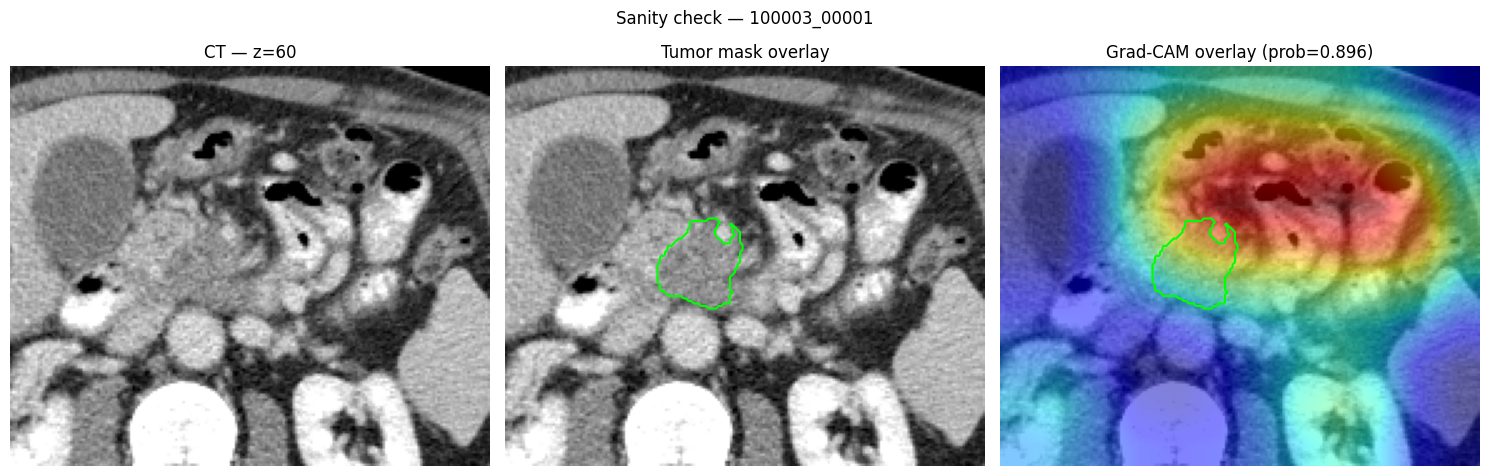

In [6]:
# ============================================================
# CELL 6 — SINGLE-CASE SANITY CHECK
# ============================================================

ALLOW_PROCEED_ON_SANITY_FAILURE = False  # do not flip this without understanding why a check failed

sample_row = pdac_test_df.iloc[0]
sample_volume, sample_tumor_mask, sample_raw_mask = load_volume_and_mask(
    sample_row, PROCESSED_DIR, return_raw_mask=True
)

sample_tumor_voxels = int(sample_tumor_mask.sum())
tumor_coords = np.argwhere(sample_tumor_mask)
bbox = (
    tuple(tumor_coords.min(axis=0).tolist()),
    tuple(tumor_coords.max(axis=0).tolist()),
) if len(tumor_coords) > 0 else None

print("=" * 70)
print("SINGLE-CASE SANITY CHECK")
print("=" * 70)
print(f"Study ID           : {sample_row['study_id']}")
print(f"Image shape        : {sample_volume.shape}")
print(f"Mask shape         : {sample_raw_mask.shape}")
print(f"Tumor voxel count  : {sample_tumor_voxels}")
print(f"Unique mask labels : {sorted(np.unique(sample_raw_mask).tolist())}")
print(f"Tumor bounding box : {bbox}")

shape_ok = sample_volume.shape == sample_raw_mask.shape
tumor_ok = sample_tumor_voxels > 0

gradcam_sanity = GradCAM3D(model, model.layer4)
volume_tensor = torch.from_numpy(sample_volume).unsqueeze(0).unsqueeze(0).to(DEVICE)
sample_cam, sample_probability, sample_cam_status, sample_diag = gradcam_sanity.generate(volume_tensor)
gradcam_sanity.remove_hooks()

print(f"\nCAM status         : {sample_cam_status}")
if sample_cam is not None:
    print(f"CAM shape          : {sample_cam.shape}")
    print(f"CAM min/max        : {sample_diag['cam_min']:.6f} / {sample_diag['cam_max']:.6f}")
    print(f"CAM mean           : {sample_diag['cam_mean']:.6f}")
    print(f"CAM nonzero frac.  : {sample_diag['cam_nonzero_fraction']:.4f}")
print(f"Probability        : {sample_probability:.4f}")

cam_shape_ok = sample_cam is not None and sample_cam.shape == sample_volume.shape
cam_finite = sample_cam is not None and np.isfinite(sample_cam).all()
print(f"CAM shape matches volume: {cam_shape_ok}")
print(f"CAM finite              : {cam_finite}")

sample_hit = None
if sample_cam is not None and sample_cam_status == "ok":
    peak_index = np.unravel_index(np.argmax(sample_cam), sample_cam.shape)
    sample_hit = bool(sample_tumor_mask[peak_index])
    print(f"Pointing Game result: {'HIT' if sample_hit else 'MISS'}")
else:
    print("Pointing Game result: N/A (CAM not valid)")

# ------------------------------------------------------------
# Refuse to proceed on critical failures.
# ------------------------------------------------------------

failures = []
if not shape_ok:
    failures.append("image/mask shape mismatch")
if not tumor_ok:
    failures.append("zero tumor voxels in sample case")
if sample_cam_status == "invalid":
    failures.append(f"CAM invalid ({sample_diag.get('reason')})")
if sample_cam is not None and not cam_finite:
    failures.append("CAM contains NaN/Inf")
if sample_cam is not None and not cam_shape_ok:
    failures.append("CAM shape does not match input volume")
if sample_cam_status == "degenerate":
    failures.append("CAM is degenerate (all-zero) -- check target layer / gradient flow")

if failures and not ALLOW_PROCEED_ON_SANITY_FAILURE:
    raise AssertionError(
        f"Sanity check failed: {failures}. Set ALLOW_PROCEED_ON_SANITY_FAILURE=True "
        f"only if you understand and accept why this specific check failed."
    )

print("\n✓ Sanity check passed. Safe to proceed to the full GPU loop.")

# ------------------------------------------------------------
# Visualization
# ------------------------------------------------------------

z_center = int(tumor_coords[:, 0].mean()) if len(tumor_coords) > 0 else sample_volume.shape[0] // 2

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(sample_volume[z_center], cmap="gray")
axes[0].set_title(f"CT — z={z_center}"); axes[0].axis("off")

axes[1].imshow(sample_volume[z_center], cmap="gray")
axes[1].contour(sample_tumor_mask[z_center], colors="lime", linewidths=1.5)
axes[1].set_title("Tumor mask overlay"); axes[1].axis("off")

axes[2].imshow(sample_volume[z_center], cmap="gray")
if sample_cam is not None:
    axes[2].imshow(sample_cam[z_center], cmap="jet", alpha=0.5)
axes[2].contour(sample_tumor_mask[z_center], colors="lime", linewidths=1.5)
axes[2].set_title(f"Grad-CAM overlay (prob={sample_probability:.3f})"); axes[2].axis("off")

plt.suptitle(f"Sanity check — {sample_row['study_id']}")
plt.tight_layout()
plt.show()


## Cell 7 — Metric functions

**IoU** and **Dice** require binarizing the CAM; both are computed across the full threshold sweep. **Pointing Game** is threshold-independent, but a degenerate (all-zero/constant) CAM's `argmax` is arbitrary (NumPy would return index 0), not meaningful -- such cases are marked invalid and excluded from the Pointing Game denominator rather than silently counted as a hit or miss.

In [7]:
# ============================================================
# CELL 7 — METRIC FUNCTIONS
# ============================================================

def compute_iou(cam_binary, mask_binary):
    intersection = np.logical_and(cam_binary, mask_binary).sum()
    union = np.logical_or(cam_binary, mask_binary).sum()
    return intersection / union if union > 0 else np.nan


def compute_dice(cam_binary, mask_binary):
    intersection = np.logical_and(cam_binary, mask_binary).sum()
    denom = cam_binary.sum() + mask_binary.sum()
    return (2 * intersection) / denom if denom > 0 else np.nan


def pointing_game_hit(cam, mask_binary, cam_status):
    """Returns True/False, or None if the CAM is degenerate/invalid and
    the result should be excluded from the Pointing Game denominator
    rather than treated as a meaningful hit or miss."""
    if cam_status != "ok":
        return None
    peak_index = np.unravel_index(np.argmax(cam), cam.shape)
    return bool(mask_binary[peak_index])


print("✓ IoU, Dice, and degenerate-aware Pointing Game functions defined.")


✓ IoU, Dice, and degenerate-aware Pointing Game functions defined.


## Cell 8 — Main loop: Grad-CAM generation for all PDAC test cases (Analysis A basis)

This is the GPU-consuming step -- one forward and one backward pass per case. Per-case results include everything needed for both Analysis A (all cases, computed here) and Analysis B (correctly-predicted subset, filtered from this same table in Cell 9 -- no second GPU pass).

In [8]:
# ============================================================
# CELL 8 — MAIN LOOP: GRAD-CAM + METRICS FOR ALL PDAC TEST CASES
# ============================================================

gradcam = GradCAM3D(model, model.layer4)

results = []
saved_cam_volumes = {}

print("=" * 70)
print(f"GENERATING GRAD-CAM FOR {len(pdac_test_df)} PDAC TEST CASES (Analysis A basis)")
print("=" * 70)

for i, row in pdac_test_df.iterrows():
    study_id = row["study_id"]

    volume, tumor_mask = load_volume_and_mask(row, PROCESSED_DIR)
    tumor_voxel_count = int(tumor_mask.sum())

    volume_tensor = torch.from_numpy(volume).unsqueeze(0).unsqueeze(0).to(DEVICE)
    cam, probability, cam_status, diag = gradcam.generate(volume_tensor)

    predicted_label = int(probability >= PREDICTION_THRESHOLD)
    correct_prediction = bool(predicted_label == 1)  # true label is PDAC for every row here

    row_result = {
        "study_id": study_id,
        "probability": probability,
        "predicted_label": predicted_label,
        "correct_prediction": correct_prediction,
        "tumor_voxel_count": tumor_voxel_count,
        "cam_status": cam_status,
        "cam_degenerate": cam_status == "degenerate",
        "roi_boundary_case": study_id in ROI_BOUNDARY_CASE_IDS,
    }
    row_result.update(diag if cam is not None else {"cam_max": np.nan, "cam_min": np.nan, "cam_mean": np.nan, "cam_nonzero_fraction": np.nan})

    hit = pointing_game_hit(cam, tumor_mask, cam_status) if cam is not None else None
    row_result["pointing_game_hit"] = hit

    for threshold in IOU_DICE_THRESHOLDS:
        if cam is not None and cam_status == "ok":
            cam_binary = cam >= threshold
            row_result[f"iou_t{threshold}"] = compute_iou(cam_binary, tumor_mask)
            row_result[f"dice_t{threshold}"] = compute_dice(cam_binary, tumor_mask)
        else:
            row_result[f"iou_t{threshold}"] = np.nan
            row_result[f"dice_t{threshold}"] = np.nan

    results.append(row_result)

    if SAVE_ALL_CAM_VOLUMES and cam is not None:
        saved_cam_volumes[study_id] = cam

    if (i + 1) % 20 == 0 or (i + 1) == len(pdac_test_df):
        print(f"  Processed {i+1}/{len(pdac_test_df)}")

gradcam.remove_hooks()

results_df = pd.DataFrame(results)

n_ok = int((results_df["cam_status"] == "ok").sum())
n_degenerate = int((results_df["cam_status"] == "degenerate").sum())
n_invalid = int((results_df["cam_status"] == "invalid").sum())

print("\n" + "=" * 70)
print("GRAD-CAM GENERATION COMPLETE")
print("=" * 70)
print(f"Cases evaluated : {len(results_df)}")
print(f"  status=ok        : {n_ok}")
print(f"  status=degenerate: {n_degenerate}")
print(f"  status=invalid   : {n_invalid}")
if n_degenerate + n_invalid > 0:
    print(
        "\nNOTE: degenerate/invalid cases are excluded from IoU/Dice/Pointing "
        "Game aggregates below (NaN), not silently treated as successes or failures."
    )

display(results_df.head())


GENERATING GRAD-CAM FOR 103 PDAC TEST CASES (Analysis A basis)
  Processed 20/103
  Processed 40/103
  Processed 60/103
  Processed 80/103
  Processed 100/103
  Processed 103/103

GRAD-CAM GENERATION COMPLETE
Cases evaluated : 103
  status=ok        : 103
  status=degenerate: 0
  status=invalid   : 0


,study_id,probability,predicted_label,correct_prediction,tumor_voxel_count,cam_status,cam_degenerate,roi_boundary_case,cam_min,cam_max,...,iou_t0.3,dice_t0.3,iou_t0.4,dice_t0.4,iou_t0.5,dice_t0.5,iou_t0.6,dice_t0.6,iou_t0.7,dice_t0.7
0,100003_00001,0.895962,1,True,6412,ok,False,False,0.0,0.016038,...,0.010385,0.020556,0.012880,0.025432,0.014367,0.028328,0.014730,0.029032,0.010979,0.021719
1,100016_00001,0.137025,0,False,128,ok,False,False,0.0,0.013911,...,0.000287,0.000574,0.000099,0.000198,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,100034_00001,0.969535,1,True,5436,ok,False,False,0.0,0.011845,...,0.005513,0.010965,0.007630,0.015144,0.009881,0.019568,0.010790,0.021350,0.010449,0.020682
3,100060_00001,0.639685,1,True,614,ok,False,False,0.0,0.006826,...,0.000953,0.001904,0.000700,0.001399,0.000147,0.000295,0.000000,0.000000,0.000000,0.000000
4,100134_00001,0.849659,1,True,124934,ok,False,False,0.0,0.011480,...,0.007968,0.015810,0.003171,0.006322,0.000951,0.001900,0.000021,0.000041,0.000000,0.000000


## Cell 9 — Analysis A vs. Analysis B

**Analysis A** (all PDAC-positive test cases) uses the full `results_df` above. **Analysis B** (correctly predicted PDAC cases only) filters that same table to `correct_prediction == True` -- no additional GPU work is performed.

In [9]:
# ============================================================
# CELL 9 — DEFINE ANALYSIS A AND ANALYSIS B SUBSETS
# ============================================================

analysis_a_df = results_df.copy()
analysis_b_df = results_df[results_df["correct_prediction"] == True].copy()

print("=" * 70)
print("ANALYSIS A vs. ANALYSIS B")
print("=" * 70)
print(f"Analysis A (all PDAC-positive test cases)      : N = {len(analysis_a_df)}")
print(f"Analysis B (correctly predicted PDAC cases only): N = {len(analysis_b_df)}")
print(f"  ({len(analysis_a_df) - len(analysis_b_df)} PDAC cases were misclassified as non-PDAC "
      f"and are included in A but excluded from B)")


ANALYSIS A vs. ANALYSIS B
Analysis A (all PDAC-positive test cases)      : N = 103
Analysis B (correctly predicted PDAC cases only): N = 71
  (32 PDAC cases were misclassified as non-PDAC and are included in A but excluded from B)


## Cell 10 — Threshold sensitivity with distribution statistics

Mean, median, standard deviation, and valid-case count are reported for every threshold, for both Analysis A and Analysis B. Medians matter here because Grad-CAM localization scores can have outliers that skew the mean.

ANALYSIS A — THRESHOLD SENSITIVITY (all PDAC-positive test cases)


,threshold,mean_iou,median_iou,sd_iou,mean_dice,median_dice,sd_dice,n_valid
0,0.3,0.002385,0.000522,0.003530,0.004733,0.001043,0.006986,103
1,0.4,0.002890,0.000464,0.004592,0.005723,0.000927,0.009051,103
2,0.5,0.003260,0.000000,0.006360,0.006421,0.000000,0.012450,103
3,0.6,0.003778,0.000000,0.008525,0.007389,0.000000,0.016519,103
4,0.7,0.003570,0.000000,0.010560,0.006905,0.000000,0.020160,103



ANALYSIS B — THRESHOLD SENSITIVITY (correctly predicted PDAC cases)


,threshold,mean_iou,median_iou,sd_iou,mean_dice,median_dice,sd_dice,n_valid
0,0.3,0.002854,0.001219,0.003526,0.005667,0.002435,0.006979,71
1,0.4,0.003632,0.001133,0.004839,0.007193,0.002262,0.009538,71
2,0.5,0.004150,0.000592,0.006992,0.008171,0.001182,0.013678,71
3,0.6,0.004907,0.000000,0.009578,0.009592,0.000000,0.018535,71
4,0.7,0.004641,0.000000,0.012070,0.008966,0.000000,0.022998,71


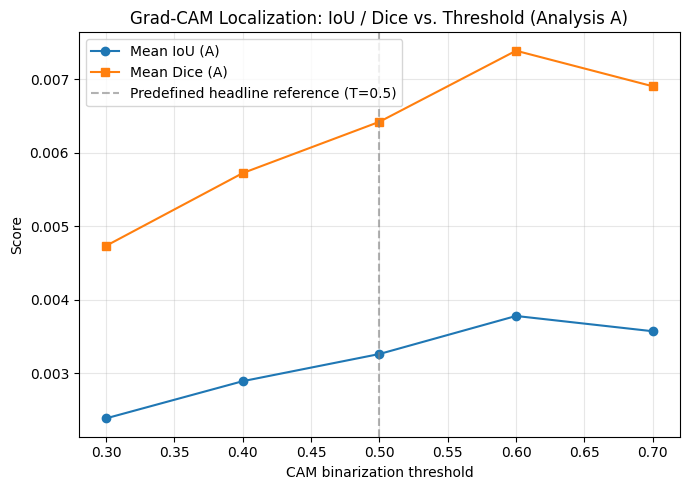


Saved: /kaggle/working/gradcam_results/iou_dice_threshold_sensitivity.png


In [10]:
# ============================================================
# CELL 10 — THRESHOLD SENSITIVITY TABLES (BOTH ANALYSES)
# ============================================================

def threshold_sensitivity_table(df, thresholds):
    rows = []
    for threshold in thresholds:
        iou_col, dice_col = f"iou_t{threshold}", f"dice_t{threshold}"
        iou_valid = df[iou_col].dropna()
        dice_valid = df[dice_col].dropna()
        rows.append({
            "threshold": threshold,
            "mean_iou": iou_valid.mean(), "median_iou": iou_valid.median(), "sd_iou": iou_valid.std(),
            "mean_dice": dice_valid.mean(), "median_dice": dice_valid.median(), "sd_dice": dice_valid.std(),
            "n_valid": len(dice_valid),
        })
    return pd.DataFrame(rows)


threshold_summary_a = threshold_sensitivity_table(analysis_a_df, IOU_DICE_THRESHOLDS)
threshold_summary_b = threshold_sensitivity_table(analysis_b_df, IOU_DICE_THRESHOLDS)

print("=" * 70)
print("ANALYSIS A — THRESHOLD SENSITIVITY (all PDAC-positive test cases)")
print("=" * 70)
display(threshold_summary_a)

print("\n" + "=" * 70)
print("ANALYSIS B — THRESHOLD SENSITIVITY (correctly predicted PDAC cases)")
print("=" * 70)
display(threshold_summary_b)

# ------------------------------------------------------------
# Plot (Analysis A; Analysis B pattern is typically similar and is
# available in the saved CSV for direct comparison).
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(threshold_summary_a["threshold"], threshold_summary_a["mean_iou"], "o-", label="Mean IoU (A)")
ax.plot(threshold_summary_a["threshold"], threshold_summary_a["mean_dice"], "s-", label="Mean Dice (A)")
ax.axvline(HEADLINE_THRESHOLD, color="gray", linestyle="--", alpha=0.6,
           label=f"Predefined headline reference (T={HEADLINE_THRESHOLD})")
ax.set_xlabel("CAM binarization threshold")
ax.set_ylabel("Score")
ax.set_title("Grad-CAM Localization: IoU / Dice vs. Threshold (Analysis A)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()

threshold_plot_path = OUTPUT_DIR / "iou_dice_threshold_sensitivity.png"
plt.savefig(threshold_plot_path, dpi=200, bbox_inches="tight")
plt.show()
print("\nSaved:", threshold_plot_path)


## Cell 11 — Bootstrap confidence intervals (case-level, both analyses)

The independent resampling unit is the **case**, not the voxel. The bootstrap function is robust to zero or one valid case and to NaNs, returning NaN with a warning rather than crashing or silently misreporting.

In [11]:
# ============================================================
# CELL 11 — CASE-LEVEL BOOTSTRAP CONFIDENCE INTERVALS
# ============================================================

def bootstrap_mean_ci(values, n_bootstrap=N_BOOTSTRAP, seed=SEED):
    """Case-level bootstrap (never voxel-level). Robust to 0/1 valid
    cases and NaNs -- returns (point_estimate, ci_low, ci_high, n_valid),
    with NaN CI and a printed warning if bootstrapping is not possible."""
    values = np.asarray(values, dtype=float)
    values = values[~np.isnan(values)]
    n = len(values)

    if n == 0:
        print("  WARNING: 0 valid cases -- cannot compute point estimate or CI.")
        return np.nan, np.nan, np.nan, 0
    if n == 1:
        print("  WARNING: only 1 valid case -- point estimate reported, CI undefined.")
        return values[0], np.nan, np.nan, 1

    point_estimate = values.mean()
    rng = np.random.default_rng(seed)
    boot_means = [values[rng.integers(0, n, size=n)].mean() for _ in range(n_bootstrap)]
    ci_low, ci_high = np.percentile(boot_means, [2.5, 97.5])
    return point_estimate, ci_low, ci_high, n


def summarize_with_ci(df, label):
    print(f"\n--- {label} (N={len(df)}) ---")
    summary_rows = []

    for threshold in [HEADLINE_THRESHOLD]:
        for metric_name, col in [("IoU", f"iou_t{threshold}"), ("Dice", f"dice_t{threshold}")]:
            point, lo, hi, n_valid = bootstrap_mean_ci(df[col])
            print(f"{metric_name} @ T={threshold}: {point:.4f}  (95% CI: [{lo:.4f}, {hi:.4f}], N_valid={n_valid})")
            summary_rows.append({"metric": metric_name, "threshold": threshold,
                                  "point_estimate": point, "ci_low": lo, "ci_high": hi, "n_valid": n_valid})

    pg_valid = df["pointing_game_hit"].dropna()
    pg_point, pg_lo, pg_hi, pg_n = bootstrap_mean_ci(pg_valid.astype(float))
    n_hits = int(pg_valid.sum()) if len(pg_valid) > 0 else 0
    print(f"Pointing Game: {n_hits}/{pg_n} = {pg_point:.4f}  (95% CI: [{pg_lo:.4f}, {pg_hi:.4f}])")
    summary_rows.append({"metric": "Pointing Game", "threshold": "n/a",
                          "point_estimate": pg_point, "ci_low": pg_lo, "ci_high": pg_hi, "n_valid": pg_n})

    return pd.DataFrame(summary_rows)


print("=" * 70)
print(f"BOOTSTRAP 95% CONFIDENCE INTERVALS ({N_BOOTSTRAP} resamples, case-level)")
print("=" * 70)

summary_a_ci = summarize_with_ci(analysis_a_df, "ANALYSIS A — all PDAC-positive test cases")
summary_b_ci = summarize_with_ci(analysis_b_df, "ANALYSIS B — correctly predicted PDAC cases")


BOOTSTRAP 95% CONFIDENCE INTERVALS (2000 resamples, case-level)

--- ANALYSIS A — all PDAC-positive test cases (N=103) ---
IoU @ T=0.5: 0.0033  (95% CI: [0.0021, 0.0046], N_valid=103)
Dice @ T=0.5: 0.0064  (95% CI: [0.0041, 0.0090], N_valid=103)
Pointing Game: 0/103 = 0.0000  (95% CI: [0.0000, 0.0000])

--- ANALYSIS B — correctly predicted PDAC cases (N=71) ---
IoU @ T=0.5: 0.0041  (95% CI: [0.0026, 0.0059], N_valid=71)
Dice @ T=0.5: 0.0082  (95% CI: [0.0052, 0.0116], N_valid=71)
Pointing Game: 0/71 = 0.0000  (95% CI: [0.0000, 0.0000])


## Cell 12 — Qualitative examples: Best / Median / Worst by Dice (Analysis A)

Three examples are selected objectively using Dice at the predefined reference threshold (T=0.5): **Worst** = minimum valid Dice, **Median** = the case whose Dice is numerically closest to the actual median value (not the middle row of a sorted table, which only coincidentally equals the median for an odd case count), **Best** = maximum valid Dice.

The main figure shows the tumor-center axial slice for each case across four panels: CT, CT+ground-truth contour, CT+continuous CAM+contour, and CT+thresholded CAM+contour -- connecting the quantitative Dice/IoU number directly to what was actually measured.

Because a tumor-centered slice may not reveal where the strongest CAM activation actually occurs, a separate tumor-center-vs-CAM-peak comparison (plus a simple z-axis max-intensity projection) is additionally generated **for the objectively-selected worst case specifically** -- this is where hidden poor localization is most likely to matter, not a claim that every example gets this second view.

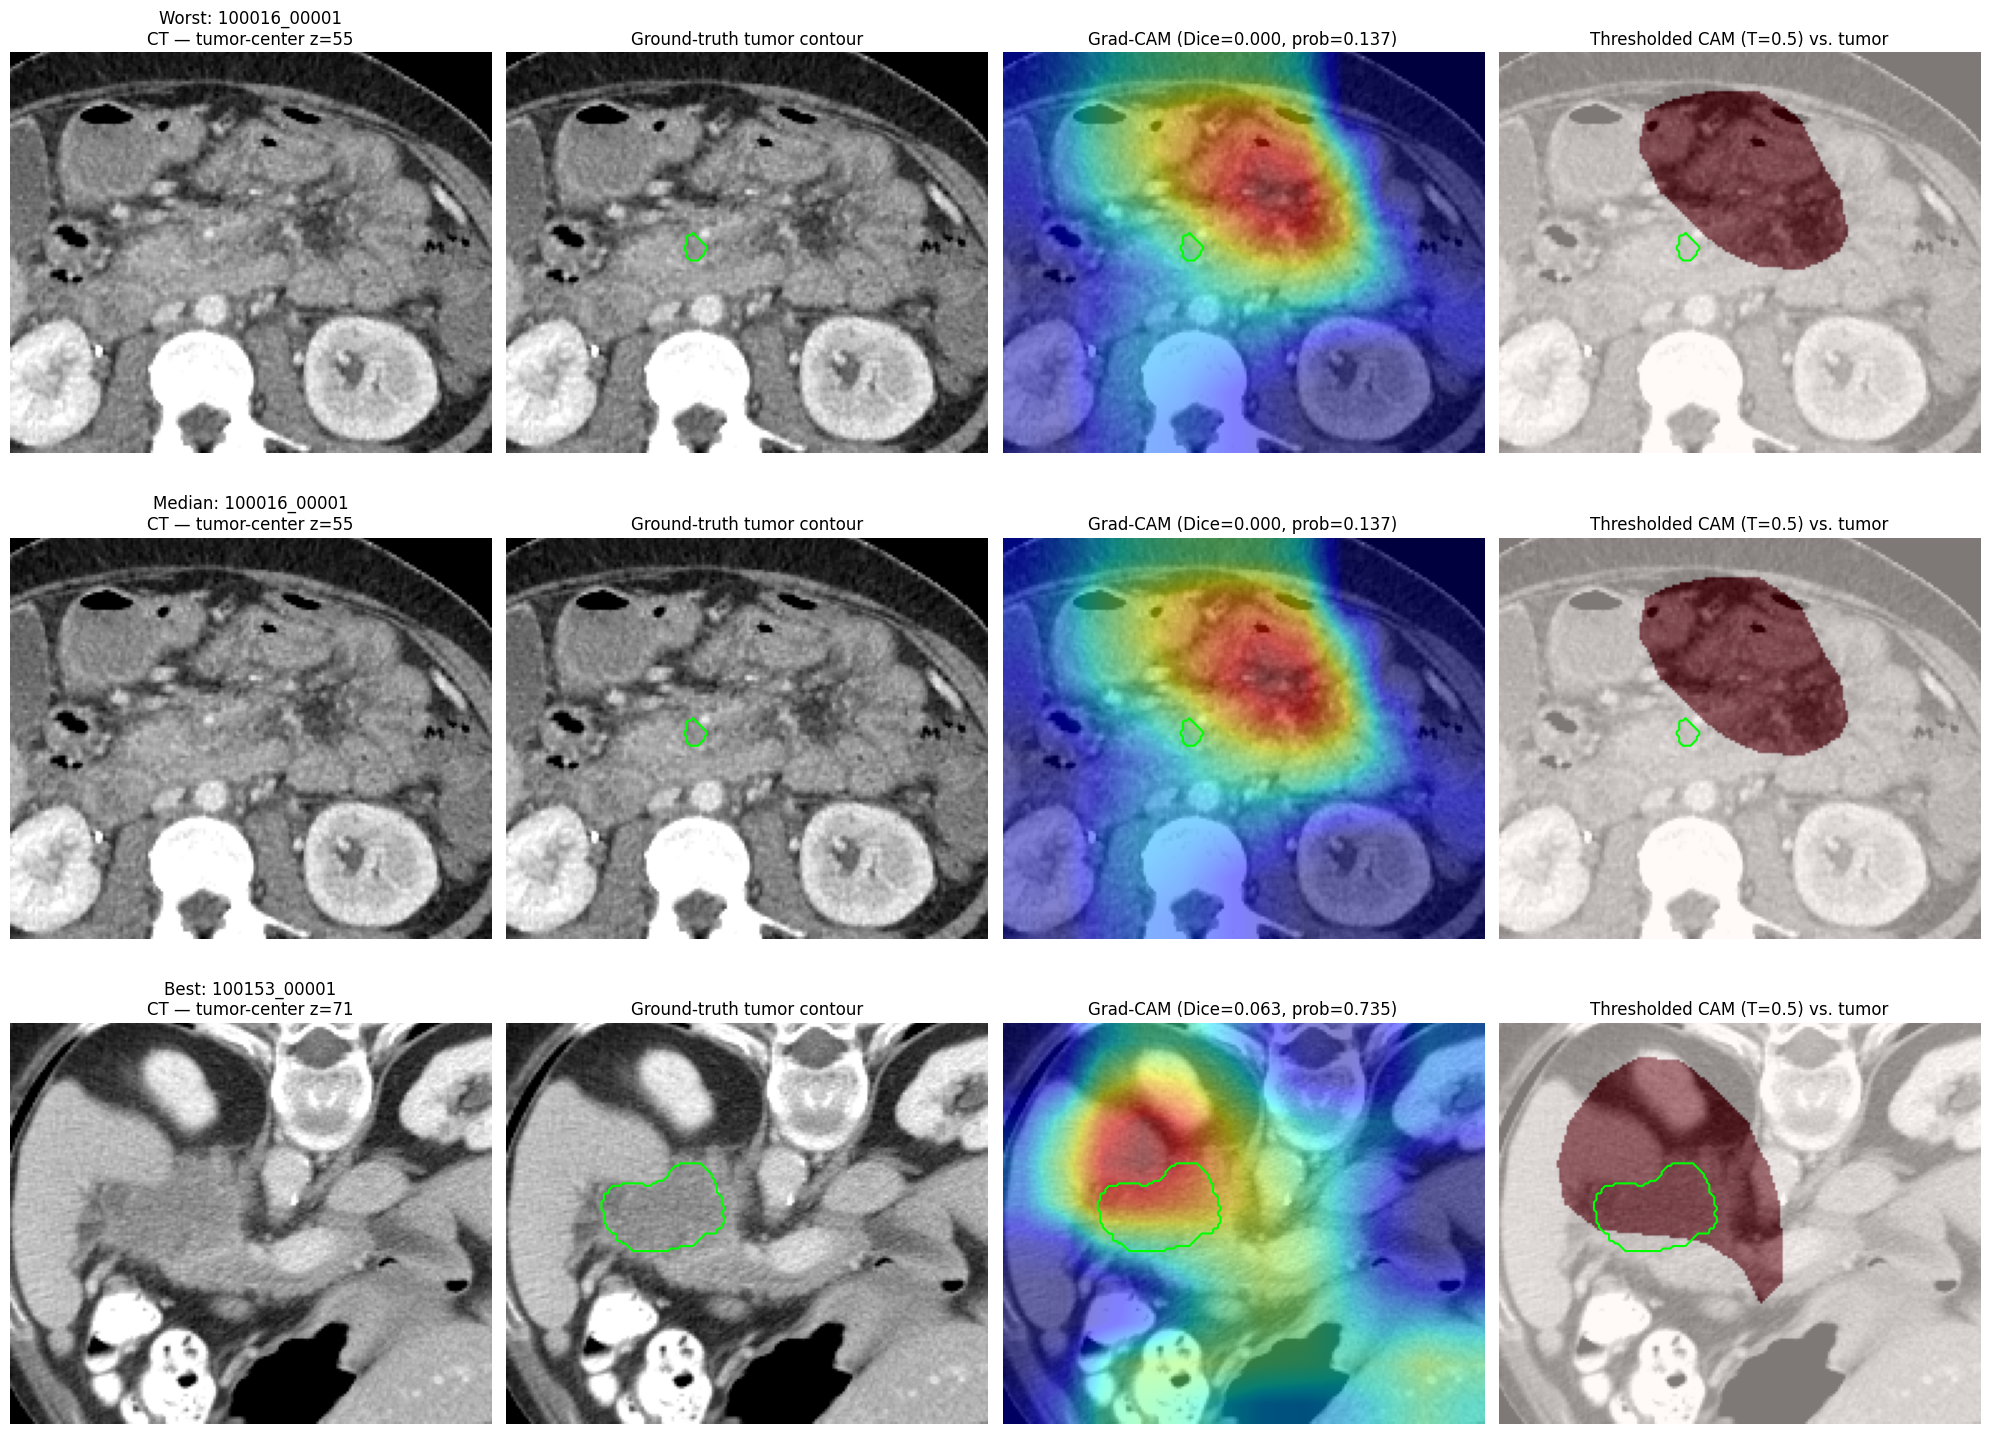

Saved: /kaggle/working/gradcam_results/gradcam_qualitative_examples.png


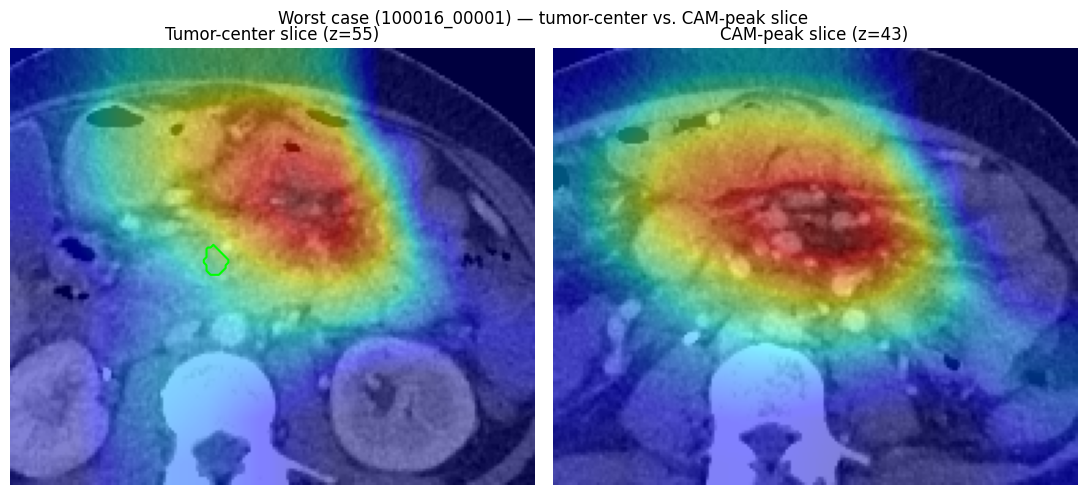

Saved: /kaggle/working/gradcam_results/gradcam_worst_case_peak_view.png


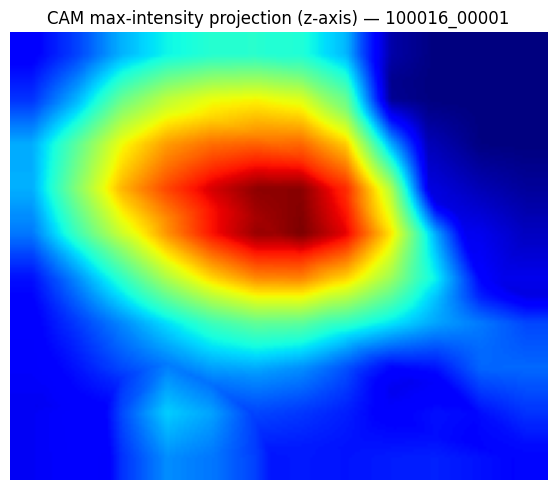

Saved: /kaggle/working/gradcam_results/gradcam_worst_case_mip.png


In [12]:
# ============================================================
# CELL 12 — BEST / MEDIAN / WORST QUALITATIVE EXAMPLES
# ============================================================

dice_col = f"dice_t{HEADLINE_THRESHOLD}"
valid_a = analysis_a_df.dropna(subset=[dice_col]).reset_index(drop=True)

median_dice_value = valid_a[dice_col].median()
median_idx = (valid_a[dice_col] - median_dice_value).abs().idxmin()  # closest-to-median case, not the middle row
worst_idx = valid_a[dice_col].idxmin()
best_idx = valid_a[dice_col].idxmax()

example_indices = {"Worst": worst_idx, "Median": median_idx, "Best": best_idx}

fig, axes = plt.subplots(len(example_indices), 4, figsize=(20, 5 * len(example_indices)))

for row_idx, (label, idx) in enumerate(example_indices.items()):
    summary_row = valid_a.loc[idx]
    study_id = summary_row["study_id"]
    dice_value = summary_row[dice_col]

    full_row = pdac_test_df[pdac_test_df["study_id"] == study_id].iloc[0]
    volume, tumor_mask = load_volume_and_mask(full_row, PROCESSED_DIR)
    volume_tensor = torch.from_numpy(volume).unsqueeze(0).unsqueeze(0).to(DEVICE)

    gradcam_viz = GradCAM3D(model, model.layer4)
    cam, probability, cam_status, _ = gradcam_viz.generate(volume_tensor)
    gradcam_viz.remove_hooks()

    tumor_coords = np.argwhere(tumor_mask)
    z_center = int(tumor_coords[:, 0].mean()) if len(tumor_coords) > 0 else volume.shape[0] // 2
    z_peak = int(np.unravel_index(np.argmax(cam), cam.shape)[0]) if cam is not None else z_center

    ax0, ax1, ax2, ax3 = axes[row_idx]

    ax0.imshow(volume[z_center], cmap="gray")
    ax0.set_title(f"{label}: {study_id}\nCT — tumor-center z={z_center}")
    ax0.axis("off")

    ax1.imshow(volume[z_center], cmap="gray")
    ax1.contour(tumor_mask[z_center], colors="lime", linewidths=1.5)
    ax1.set_title("Ground-truth tumor contour")
    ax1.axis("off")

    ax2.imshow(volume[z_center], cmap="gray")
    if cam is not None:
        ax2.imshow(cam[z_center], cmap="jet", alpha=0.5)
    ax2.contour(tumor_mask[z_center], colors="lime", linewidths=1.5)
    ax2.set_title(f"Grad-CAM (Dice={dice_value:.3f}, prob={probability:.3f})")
    ax2.axis("off")

    ax3.imshow(volume[z_center], cmap="gray")
    if cam is not None:
        ax3.imshow(cam[z_center] >= HEADLINE_THRESHOLD, cmap="Reds", alpha=0.5)
    ax3.contour(tumor_mask[z_center], colors="lime", linewidths=1.5)
    ax3.set_title(f"Thresholded CAM (T={HEADLINE_THRESHOLD}) vs. tumor")
    ax3.axis("off")

    saved_cam_volumes[study_id] = cam if cam is not None else np.zeros_like(volume)

plt.tight_layout()
examples_plot_path = OUTPUT_DIR / "gradcam_qualitative_examples.png"
plt.savefig(examples_plot_path, dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", examples_plot_path)

# ------------------------------------------------------------
# Secondary CAM-peak-slice view for the "Worst" case specifically --
# this is the case most likely to have its strongest activation NOT at
# the tumor center, which the panel above alone could hide.
# ------------------------------------------------------------

worst_row = valid_a.loc[worst_idx]
worst_study_id = worst_row["study_id"]
worst_full_row = pdac_test_df[pdac_test_df["study_id"] == worst_study_id].iloc[0]
worst_volume, worst_tumor_mask = load_volume_and_mask(worst_full_row, PROCESSED_DIR)
worst_cam = saved_cam_volumes[worst_study_id]

worst_tumor_coords = np.argwhere(worst_tumor_mask)
worst_z_center = int(worst_tumor_coords[:, 0].mean()) if len(worst_tumor_coords) > 0 else worst_volume.shape[0] // 2
worst_z_peak = int(np.unravel_index(np.argmax(worst_cam), worst_cam.shape)[0])

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
axes[0].imshow(worst_volume[worst_z_center], cmap="gray")
axes[0].imshow(worst_cam[worst_z_center], cmap="jet", alpha=0.5)
axes[0].contour(worst_tumor_mask[worst_z_center], colors="lime", linewidths=1.5)
axes[0].set_title(f"Tumor-center slice (z={worst_z_center})")
axes[0].axis("off")

axes[1].imshow(worst_volume[worst_z_peak], cmap="gray")
axes[1].imshow(worst_cam[worst_z_peak], cmap="jet", alpha=0.5)
axes[1].contour(worst_tumor_mask[worst_z_peak], colors="lime", linewidths=1.5)
axes[1].set_title(f"CAM-peak slice (z={worst_z_peak})")
axes[1].axis("off")

plt.suptitle(f"Worst case ({worst_study_id}) — tumor-center vs. CAM-peak slice")
plt.tight_layout()
peak_view_path = OUTPUT_DIR / "gradcam_worst_case_peak_view.png"
plt.savefig(peak_view_path, dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", peak_view_path)

# Simple max-intensity projection along z for the same worst case --
# lightweight, no interactive 3D viewer needed.
fig, ax = plt.subplots(figsize=(6, 5))
mip = worst_cam.max(axis=0)
ax.imshow(mip, cmap="jet")
ax.set_title(f"CAM max-intensity projection (z-axis) — {worst_study_id}")
ax.axis("off")
plt.tight_layout()
mip_path = OUTPUT_DIR / "gradcam_worst_case_mip.png"
plt.savefig(mip_path, dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", mip_path)


## Cell 13 — Objective failure-case identification

Failure cases are identified using criteria fixed in Cell 1 **before** inspecting the Grad-CAM results -- predefined, not chosen after seeing the distribution. Two failure types are searched among correctly predicted, high-confidence PDAC cases (`probability >= HIGH_CONFIDENCE_THRESHOLD`): Dice below `LOW_DICE_FAILURE_THRESHOLD` at the reference threshold, and a Pointing Game miss.

These cases are not presented as proof the classifier is "right for the wrong reason" in any strong causal sense -- they are concrete examples of poor explanation localization despite a confident, correct classification, which is exactly the kind of finding that motivates continued explainability scrutiny rather than treating high test accuracy alone as sufficient evidence of trustworthiness.

In [13]:
# ============================================================
# CELL 13 — OBJECTIVE FAILURE CASE SEARCH
# ============================================================

confident_correct = analysis_a_df[
    (analysis_a_df["correct_prediction"] == True)
    & (analysis_a_df["probability"] >= HIGH_CONFIDENCE_THRESHOLD)
]

failure_low_dice = confident_correct[
    confident_correct[dice_col] < LOW_DICE_FAILURE_THRESHOLD
].copy()

failure_pointing_miss = confident_correct[
    confident_correct["pointing_game_hit"] == False
].copy()

failure_cases_df = pd.concat([failure_low_dice, failure_pointing_miss]).drop_duplicates(subset="study_id")

print("=" * 70)
print("OBJECTIVE FAILURE CASE SEARCH")
print("=" * 70)
print(f"Confident (p>={HIGH_CONFIDENCE_THRESHOLD}) and correctly predicted cases: {len(confident_correct)}")
print(f"  ...with Dice < {LOW_DICE_FAILURE_THRESHOLD} at T={HEADLINE_THRESHOLD}: {len(failure_low_dice)}")
print(f"  ...with a Pointing Game miss                    : {len(failure_pointing_miss)}")
print(f"Total unique failure cases identified             : {len(failure_cases_df)}")

if len(failure_cases_df) > 0:
    display(failure_cases_df[["study_id", "probability", dice_col, "pointing_game_hit", "roi_boundary_case"]])
else:
    print("\nNo cases met the predefined failure criteria.")

failure_cases_path = OUTPUT_DIR / "gradcam_failure_cases.csv"
failure_cases_df.to_csv(failure_cases_path, index=False)
print("\nSaved:", failure_cases_path)


OBJECTIVE FAILURE CASE SEARCH
Confident (p>=0.8) and correctly predicted cases: 50
  ...with Dice < 0.1 at T=0.5: 50
  ...with a Pointing Game miss                    : 50
Total unique failure cases identified             : 50


,study_id,probability,dice_t0.5,pointing_game_hit,roi_boundary_case
0,100003_00001,0.895962,0.028328,False,False
2,100034_00001,0.969535,0.019568,False,False
4,100134_00001,0.849659,0.001900,False,False
7,100157_00001,0.966253,0.010260,False,False
10,100219_00001,0.995123,0.002309,False,False
16,100394_00001,0.988009,0.000591,False,False
17,100402_00001,0.819493,0.009894,False,False
19,100407_00001,0.987502,0.000029,False,False
20,100424_00001,0.908439,0.006871,False,False
26,100649_00001,0.988263,0.001182,False,False



Saved: /kaggle/working/gradcam_results/gradcam_failure_cases.csv


## Cell 14 — Classification confidence vs. localization quality

An exploratory, correlational analysis (Spearman, appropriate for a bounded, non-normal metric like Dice) relating predicted probability to Dice score. **No causal claim is made** -- this complements, but does not replace, the separate calibration analysis notebook.

CLASSIFICATION CONFIDENCE vs. LOCALIZATION QUALITY (exploratory)
N cases                : 103
Spearman rank correlation: 0.2865  (p=0.0034)
Pearson correlation      : 0.1992  (p=0.0437)

This is a correlational, exploratory analysis on a modest sample -- it should NOT be interpreted as evidence that confidence causes better (or worse) localization. It complements, and is separate from, the calibration analysis notebook (which evaluates whether confidence values are themselves reliable, a different question entirely).


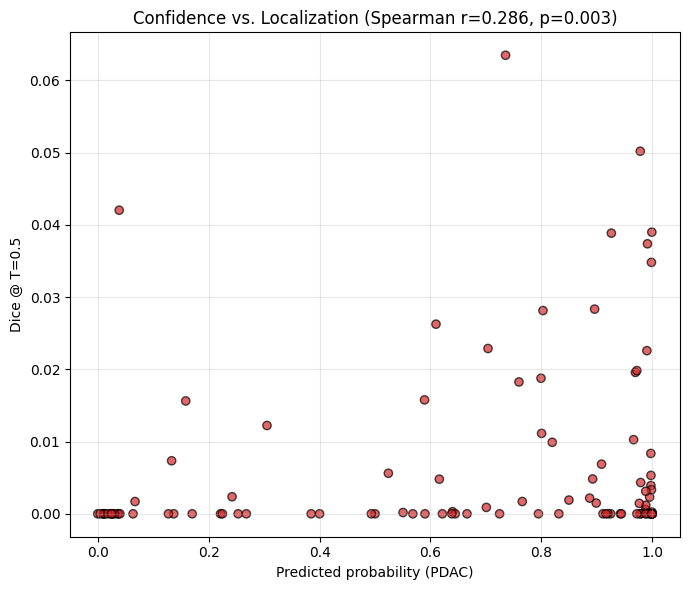


Saved: /kaggle/working/gradcam_results/gradcam_confidence_vs_dice.png
Saved: /kaggle/working/gradcam_results/gradcam_confidence_vs_dice.csv


In [14]:
# ============================================================
# CELL 14 — CONFIDENCE VS. LOCALIZATION (EXPLORATORY, NO CAUSAL CLAIM)
# ============================================================

confidence_vs_dice_df = analysis_a_df.dropna(subset=[dice_col])[["study_id", "probability", dice_col, "pointing_game_hit"]].copy()
confidence_vs_dice_df.columns = ["study_id", "probability", "dice", "pointing_game_hit"]

spearman_corr, spearman_p = stats.spearmanr(confidence_vs_dice_df["probability"], confidence_vs_dice_df["dice"])
pearson_corr, pearson_p = stats.pearsonr(confidence_vs_dice_df["probability"], confidence_vs_dice_df["dice"])

print("=" * 70)
print("CLASSIFICATION CONFIDENCE vs. LOCALIZATION QUALITY (exploratory)")
print("=" * 70)
print(f"N cases                : {len(confidence_vs_dice_df)}")
print(f"Spearman rank correlation: {spearman_corr:.4f}  (p={spearman_p:.4f})")
print(f"Pearson correlation      : {pearson_corr:.4f}  (p={pearson_p:.4f})")
print(
    "\nThis is a correlational, exploratory analysis on a modest sample -- "
    "it should NOT be interpreted as evidence that confidence causes better "
    "(or worse) localization. It complements, and is separate from, the "
    "calibration analysis notebook (which evaluates whether confidence "
    "values are themselves reliable, a different question entirely)."
)

fig, ax = plt.subplots(figsize=(7, 6))
colors = confidence_vs_dice_df["pointing_game_hit"].map({True: "tab:green", False: "tab:red"}).fillna("gray")
ax.scatter(confidence_vs_dice_df["probability"], confidence_vs_dice_df["dice"], c=colors, alpha=0.7, edgecolor="black")
ax.set_xlabel("Predicted probability (PDAC)")
ax.set_ylabel(f"Dice @ T={HEADLINE_THRESHOLD}")
ax.set_title(f"Confidence vs. Localization (Spearman r={spearman_corr:.3f}, p={spearman_p:.3f})")
ax.grid(alpha=0.3)
plt.tight_layout()

confidence_plot_path = OUTPUT_DIR / "gradcam_confidence_vs_dice.png"
plt.savefig(confidence_plot_path, dpi=200, bbox_inches="tight")
plt.show()
print("\nSaved:", confidence_plot_path)

confidence_vs_dice_path = OUTPUT_DIR / "gradcam_confidence_vs_dice.csv"
confidence_vs_dice_df.to_csv(confidence_vs_dice_path, index=False)
print("Saved:", confidence_vs_dice_path)


## Cell 15 — Save all outputs

In [15]:
# ============================================================
# CELL 15 — SAVE ALL OUTPUTS
# ============================================================

per_case_path = OUTPUT_DIR / "gradcam_per_case_results.csv"
results_df.to_csv(per_case_path, index=False)
print("Saved:", per_case_path)

threshold_summary_a_path = OUTPUT_DIR / "gradcam_threshold_sensitivity.csv"
threshold_summary_a.assign(analysis="A").to_csv(threshold_summary_a_path, index=False)
threshold_summary_b_path = OUTPUT_DIR / "gradcam_threshold_sensitivity_analysisB.csv"
threshold_summary_b.assign(analysis="B").to_csv(threshold_summary_b_path, index=False)
print("Saved:", threshold_summary_a_path)
print("Saved:", threshold_summary_b_path)

summary_ci_path = OUTPUT_DIR / "gradcam_summary_with_ci.csv"
summary_a_ci.assign(analysis="A").to_csv(summary_ci_path, index=False)
print("Saved:", summary_ci_path)

correct_pdac_summary_path = OUTPUT_DIR / "gradcam_correctly_predicted_pdac_summary.csv"
summary_b_ci.assign(analysis="B").to_csv(correct_pdac_summary_path, index=False)
print("Saved:", correct_pdac_summary_path)

if saved_cam_volumes:
    CAM_VOLUME_DIR.mkdir(exist_ok=True)
    for study_id, cam in saved_cam_volumes.items():
        np.save(CAM_VOLUME_DIR / f"{study_id}_cam.npy", cam.astype(np.float32))
    print(f"Saved {len(saved_cam_volumes)} CAM volume(s) to:", CAM_VOLUME_DIR)

# Reproducibility record.
config_record = {
    "seed": SEED,
    "checkpoint_path": str(CHECKPOINT_PATH),
    "checkpoint_epoch": int(checkpoint["epoch"]),
    "target_layer": "model.layer4",
    "pdac_tumor_label": PDAC_TUMOR_LABEL,
    "pancreas_label": PANCREAS_LABEL,
    "iou_dice_thresholds": IOU_DICE_THRESHOLDS,
    "headline_threshold": HEADLINE_THRESHOLD,
    "prediction_threshold": PREDICTION_THRESHOLD,
    "high_confidence_threshold": HIGH_CONFIDENCE_THRESHOLD,
    "low_dice_failure_threshold": LOW_DICE_FAILURE_THRESHOLD,
    "n_bootstrap": N_BOOTSTRAP,
    "n_pdac_test_cases_evaluated": len(results_df),
    "n_analysis_b_cases": len(analysis_b_df),
    "roi_boundary_case_ids": ROI_BOUNDARY_CASE_IDS,
    "generated_at": datetime.now().isoformat(),
}
config_path = OUTPUT_DIR / "gradcam_run_config.json"
with open(config_path, "w") as f:
    json_module.dump(config_record, f, indent=2)
print("Saved:", config_path)

print("\nAll Grad-CAM outputs saved to:", OUTPUT_DIR)
print("Remember: download these before the Kaggle session ends.")


Saved: /kaggle/working/gradcam_results/gradcam_per_case_results.csv
Saved: /kaggle/working/gradcam_results/gradcam_threshold_sensitivity.csv
Saved: /kaggle/working/gradcam_results/gradcam_threshold_sensitivity_analysisB.csv
Saved: /kaggle/working/gradcam_results/gradcam_summary_with_ci.csv
Saved: /kaggle/working/gradcam_results/gradcam_correctly_predicted_pdac_summary.csv
Saved 2 CAM volume(s) to: /kaggle/working/gradcam_results/cam_volumes
Saved: /kaggle/working/gradcam_results/gradcam_run_config.json

All Grad-CAM outputs saved to: /kaggle/working/gradcam_results
Remember: download these before the Kaggle session ends.


## Cell 16 — Thesis-ready summary

In [16]:
# ============================================================
# CELL 16 — FINAL THESIS-READY SUMMARY
# ============================================================

def get_metric(summary_df, metric_name, threshold=HEADLINE_THRESHOLD):
    row = summary_df[(summary_df["metric"] == metric_name) &
                      (summary_df["threshold"].astype(str) == str(threshold))]
    if len(row) == 0:
        row = summary_df[summary_df["metric"] == metric_name]
    r = row.iloc[0]
    return r["point_estimate"], r["ci_low"], r["ci_high"], r["n_valid"]


dice_a = get_metric(summary_a_ci, "Dice")
iou_a = get_metric(summary_a_ci, "IoU")
pg_a = get_metric(summary_a_ci, "Pointing Game")

dice_b = get_metric(summary_b_ci, "Dice")
iou_b = get_metric(summary_b_ci, "IoU")
pg_b = get_metric(summary_b_ci, "Pointing Game")

print("=" * 70)
print("GRAD-CAM TRUSTWORTHINESS SUMMARY")
print("=" * 70)
print("\nCheckpoint:\n  Run 2 best checkpoint (epoch {})".format(checkpoint["epoch"]))
print("\nTarget layer:\n  model.layer4")
print(f"\nPDAC tumor label:\n  {PDAC_TUMOR_LABEL} (PANORAMA lesion label; pancreas label = {PANCREAS_LABEL}, independently audited in Cell 3)")
print(f"\nTest cases:\n  {len(test_df)}")
print(f"\nPDAC-positive test cases:\n  {len(pdac_test_df)}")
print(f"\nValid Grad-CAM cases:\n  {n_ok} (status=ok)")
print(f"\nDegenerate/invalid CAMs:\n  {n_degenerate} degenerate, {n_invalid} invalid")

print("\n" + "-" * 60)
print("ALL PDAC-POSITIVE CASES (Analysis A)")
print("-" * 60)
print(f"\nDice @ T={HEADLINE_THRESHOLD}:")
print(f"  mean point estimate = {dice_a[0]:.4f}")
print(f"  95% CI = [{dice_a[1]:.4f}, {dice_a[2]:.4f}]  (N={dice_a[3]})")
print(f"\nIoU @ T={HEADLINE_THRESHOLD}:")
print(f"  mean point estimate = {iou_a[0]:.4f}")
print(f"  95% CI = [{iou_a[1]:.4f}, {iou_a[2]:.4f}]  (N={iou_a[3]})")
print(f"\nPointing Game:")
print(f"  accuracy = {pg_a[0]:.4f}, 95% CI = [{pg_a[1]:.4f}, {pg_a[2]:.4f}]  (N={pg_a[3]})")

print("\n" + "-" * 60)
print("CORRECTLY PREDICTED PDAC CASES (Analysis B)")
print("-" * 60)
print(f"\nN = {len(analysis_b_df)}")
print(f"\nDice @ T={HEADLINE_THRESHOLD}: {dice_b[0]:.4f}  (95% CI: [{dice_b[1]:.4f}, {dice_b[2]:.4f}], N={dice_b[3]})")
print(f"IoU @ T={HEADLINE_THRESHOLD} : {iou_b[0]:.4f}  (95% CI: [{iou_b[1]:.4f}, {iou_b[2]:.4f}], N={iou_b[3]})")
print(f"Pointing Game        : {pg_b[0]:.4f}  (95% CI: [{pg_b[1]:.4f}, {pg_b[2]:.4f}], N={pg_b[3]})")

print("\n" + "-" * 60)
print("THRESHOLD SENSITIVITY (Analysis A, mean Dice)")
print("-" * 60)
for _, r in threshold_summary_a.iterrows():
    marker = "  <-- headline" if r["threshold"] == HEADLINE_THRESHOLD else ""
    print(f"T={r['threshold']}: mean_Dice={r['mean_dice']:.4f}, median_Dice={r['median_dice']:.4f}, "
          f"SD={r['sd_dice']:.4f}, N={int(r['n_valid'])}{marker}")

n_roi_boundary_in_results = int(results_df["roi_boundary_case"].sum())
if n_roi_boundary_in_results > 0:
    print(f"\nNOTE: {n_roi_boundary_in_results} known ROI-boundary case(s) "
          f"(Notebook 18) present in this evaluation -- see 'roi_boundary_case' "
          f"column in the saved per-case CSV for details.")

print(f"\nOutputs saved to:\n  {OUTPUT_DIR}")
print("=" * 70)


GRAD-CAM TRUSTWORTHINESS SUMMARY

Checkpoint:
  Run 2 best checkpoint (epoch 4)

Target layer:
  model.layer4

PDAC tumor label:
  1 (PANORAMA lesion label; pancreas label = 4, independently audited in Cell 3)

Test cases:
  337

PDAC-positive test cases:
  103

Valid Grad-CAM cases:
  103 (status=ok)

Degenerate/invalid CAMs:
  0 degenerate, 0 invalid

------------------------------------------------------------
ALL PDAC-POSITIVE CASES (Analysis A)
------------------------------------------------------------

Dice @ T=0.5:
  mean point estimate = 0.0064
  95% CI = [0.0041, 0.0090]  (N=103)

IoU @ T=0.5:
  mean point estimate = 0.0033
  95% CI = [0.0021, 0.0046]  (N=103)

Pointing Game:
  accuracy = 0.0000, 95% CI = [0.0000, 0.0000]  (N=103)

------------------------------------------------------------
CORRECTLY PREDICTED PDAC CASES (Analysis B)
------------------------------------------------------------

N = 71

Dice @ T=0.5: 0.0082  (95% CI: [0.0052, 0.0116], N=71)
IoU @ T=0.5 : 0.0

## Conclusion and limitations

This notebook evaluated whether the Run 2 3D ResNet-18 classifier's Grad-CAM attention spatially corresponds to the annotated PDAC lesion in the held-out test set, via two complementary analyses: **Analysis A** (all PDAC-positive test cases with valid lesion annotations) and **Analysis B** (the subset the classifier correctly identified using the predefined classification threshold).

**Interpretation.** Results consistent with the CAM overlapping the annotated lesion are described as *consistent with lesion-focused discriminative attention*. High Dice, IoU, or Pointing Game accuracy is **not** interpreted as definitive proof of causal explanation faithfulness -- spatial overlap demonstrates correspondence between an explanation map and a lesion annotation, not that the highlighted voxels are causally necessary for the prediction. Establishing that would require perturbation-based methods (deletion/insertion testing) not attempted here.

**Limitations to state explicitly in the thesis:**
- **Coarse spatial resolution**: Grad-CAM is generated from a downsampled feature representation; trilinear interpolation restores input dimensions but not true voxel-level precision.
- **Threshold dependence**: Dice and IoU depend on CAM binarization; the full threshold sensitivity table/plot is reported alongside the predefined T=0.5 reference, which is not claimed to be optimal.
- **Positive cases only**: quantitative localization requires an annotated lesion, restricting this analysis to PDAC-positive cases; it says nothing about why the classifier correctly rejects non-PDAC cases.
- **Analysis B can be smaller than Analysis A** because misclassified PDAC cases are excluded -- interpret alongside the classifier's overall sensitivity, not in isolation.
- **ROI-boundary cases** (`100936_00001`, `101900_00001`, flagged via `roi_boundary_case`) are included with their existing masks, not corrected -- their localization scores reflect only the retained tumor extent after cropping (Notebook 18).
- **The confidence-vs-Dice analysis (Cell 14) is exploratory and correlational**; no causal relationship is claimed.
- **No threshold, target layer, or evaluation criterion was selected after inspecting Grad-CAM results on the test set** -- all were fixed in Cell 1 in advance, matching the discipline used for checkpoint selection and temperature scaling in earlier notebooks.

**What to report in the thesis:** the Cell 16 summary (Dice/IoU/Pointing Game with 95% CIs, both analyses), the full threshold sensitivity table and plot, the four-panel best/median/worst figure with the worst-case CAM-peak comparison, and the objectively-selected failure cases as a concrete illustration of where and why explainability evaluation matters.

**Possible follow-up (not part of this notebook):** a target-layer sensitivity check (repeating this evaluation with `model.layer3` instead of `model.layer4` and reporting both honestly, rather than reporting whichever gives a better score) and/or a deletion/insertion faithfulness test, if the thesis timeline allows a second, clearly-scoped explainability experiment later.
